# 07 - Pairwise P-Value Matrix Visualization

When comparing multiple models (e.g., 5 or more), looking at a list of pairwise results can become overwhelming. The **Pairwise P-Value Matrix** (Heatmap) provides a global, bird's-eye view of all statistical comparisons in a single chart.

In `labicompare`, the `plot_pvalue_matrix` function generates a styled heatmap where:
1. **Models are sorted** by their mean performance (top-performing models appear first).
2. **Colors represent significance**: Green for significant differences, red/yellow for non-significant.
3. **Winning indicators**: Small arrows (↑ or ↓) indicate if the model in the row is significantly better or worse than the model in the column.

In this tutorial, you will learn:
1. How to generate a P-value matrix from a `ComparisonSummary`.
2. How to interpret the sorting and winning indicators.
3. How to customize the visual style for reports.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from labicompare.core.data import EvaluationData
from labicompare.stats.posthoc import wilcoxon_holm
from labicompare.plots.heatmap import plot_pvalue_matrix

df = pd.read_csv("./results.csv", index_col="dataset")
eval_data = EvaluationData(df, higher_is_better=True)
print(eval_data)

# Run the full statistical pipeline
summary = wilcoxon_holm(eval_data, alpha=0.05)
print(summary)

<EvaluationData: 127 datasets, 8 models>
ComparisonSummary(Friedman P-Value=0.0000, H0=REJECTED, Models=8)


## Step 1: Generating the Matrix

The `plot_pvalue_matrix` only needs the `ComparisonSummary` object. It automatically extracts the model names, mean performances, and adjusted p-values.

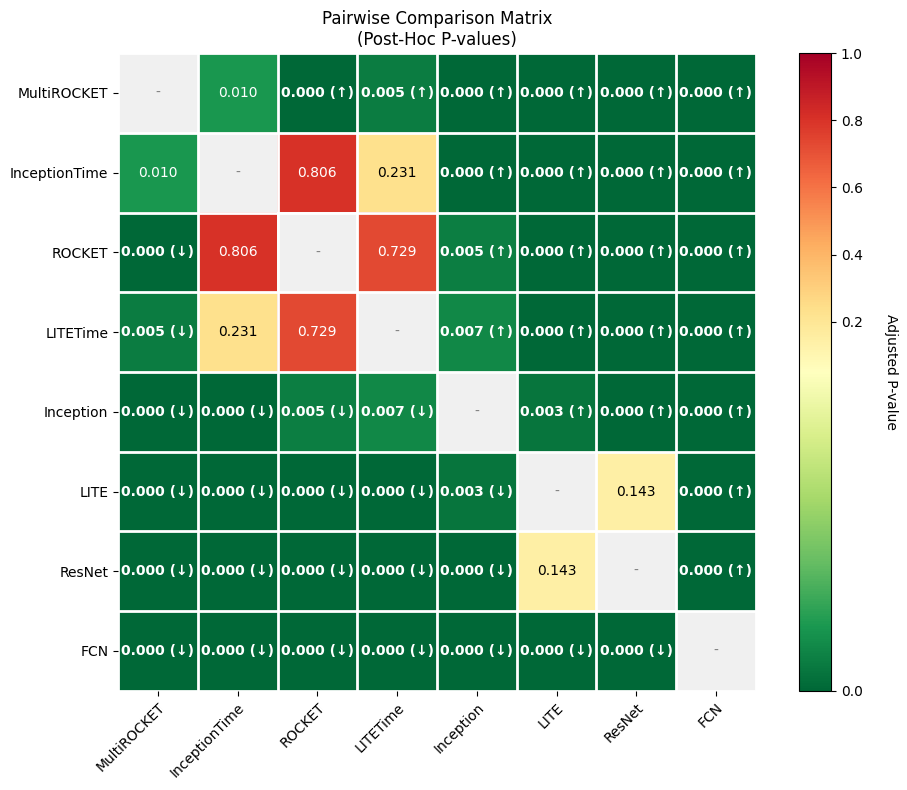

In [5]:
# Generate the heatmap
fig = plot_pvalue_matrix(
  summary=summary,
  figsize=(10, 8),
  fontsize=10
)

## How to interpret the Matrix

1. **Sorting**: Notice how `MultiROCKET` and `InceptionTime` are at the top-left. The models are automatically sorted by their mean performance across all datasets.
2. **Cells and Colors**:
  - **Green Cells**: Represent a statistically significant difference ($p \leq \alpha$).
  - **Red/Yellow Cells**: Represent models that are statistically tied.
3. **Symbols**:
  - **(↑)**: The model in the **row** is significantly better than the model in the **column**.
  - **(↓)**: The model in the **row** is significantly worse than the model in the **column**.
  - **Bold Text**: Highlights comparisons that passed the Holm significance threshold.

This visualization is particularly powerful for showing "cliques" of models that perform similarly, which are usually clustered together as blocks of red/yellow cells.